# Pipeline Unificado — Sistema Híbrido de Omni-Ensemble (SEE)

Executor fino: a lógica vive em `src/`. Rode as células de cima para baixo.

A célula **Executar** chama `generate()`, que roda T1→T8 e **regenera e sobrescreve** as tabelas e figuras em `results/` a cada execução.

## Setup — raiz do projeto + dependências

In [11]:
# Bootstrap: acha a raiz do projeto (pasta que contém src/) e ajusta path/CWD
import os, sys
root = os.getcwd()
while root != os.path.dirname(root) and not os.path.isdir(os.path.join(root, 'src')):
    root = os.path.dirname(root)
assert os.path.isdir(os.path.join(root, 'src')), 'pasta src/ nao encontrada'
os.chdir(root); sys.path.insert(0, root)
print('Raiz do projeto:', root)

Raiz do projeto: /workspaces/rp_hybrid_system_with_ensemble


In [12]:
# Instala dependencias se faltarem (seguro reexecutar). Precisa de internet.
import importlib.util, subprocess, sys
_need = {'sklearn':'scikit-learn','numpy':'numpy','scipy':'scipy',
         'pandas':'pandas','matplotlib':'matplotlib','joblib':'joblib'}
_missing = [pkg for mod,pkg in _need.items() if importlib.util.find_spec(mod) is None]
if _missing:
    print('Instalando:', _missing)
    subprocess.run([sys.executable,'-m','pip','install','-q',*_missing], check=True)
else:
    print('Todas as dependencias ja presentes.')

Todas as dependencias ja presentes.


## Visão geral do experimento

In [13]:
from src.dataset_loader import DATASETS, is_available
from src.train_pool import build_pool
from src.make_results import generate

print('Pool base (sem ensembles):', list(build_pool().keys()))
print('Bases configuradas e presentes em data/raw/:')
for nome in DATASETS:
    print(f'   {nome:<11} {"OK" if is_available(nome) else "ausente"}')

Pool base (sem ensembles): ['LR', 'SVR', 'MLP', 'kNN', 'DT']
Bases configuradas e presentes em data/raw/:
   finnish     OK
   maxwell     OK
   china       ausente
   desharnais  OK
   cocomo81    OK


## Executar o experimento e gerar resultados
Roda T1 (dados) → T2 (pool) → T3/T4 (seleção GA) → T5 (DES) → T6/T7 (métricas + Friedman),
salvando tabelas e figuras em `results/` (sobrescreve a cada execução).

In [14]:
generate()

  T1 — Carregamento e pré-processamento (dados reais, 5 bases)
----------------------------------------------------------------
[T1] ✓ 4/5 base(s) processada(s) → artefatos em data/processed/
[T1] Faltam (suba em data/raw/): ['china']
  T2 — Pool de modelos base (individuais, sem ensembles)
----------------------------------------------------------------
[T2] ✓ pool treinado em 4 base(s) (5 modelos) → matrizes em data/processed/
  T3 — SES-GA mono-objetivo (maximiza R²) — seleção OUT-OF-FOLD

── FINNISH ──

── MAXWELL ──

── DESHARNAIS ──

── COCOMO81 ──

[T3] ✓ SES-GA em 4 base(s) → results/
  T4 — SES-GA multi-objetivo (R² × parcimônia) — NSGA-II, seleção OOF

── FINNISH ──

── MAXWELL ──

── DESHARNAIS ──

── COCOMO81 ──

[T4] ✓ SES-GA-multi em 4 base(s) → results/
[DES] fit() | 283 instâncias treino | 5 modelos no pool
[DES] predict() | 122 instâncias preditas | k=7 | top=30% modelos
[DES] fit() | 43 instâncias treino | 5 modelos no pool
[DES] predict() | 19 instâncias preditas | k

## Resultados gerados

Tabela de métricas (média entre bases):


,metodo,sMAPE_medio,MRE_medio,COD_medio,rank_medio_sMAPE
0,LR,85.292,5.129,0.436,6.50
1,SVR,84.574,4.753,0.169,7.50
2,MLP,85.086,2.549,0.445,6.00
3,kNN,66.552,1.733,0.212,3.75
4,DT,67.705,1.106,0.473,3.75
5,Static,72.459,2.141,0.438,4.00
6,SES-GA,75.297,2.552,0.507,4.25
7,SES-GA-Multi,84.296,2.623,0.446,6.00
8,DES,70.742,1.303,0.301,3.25


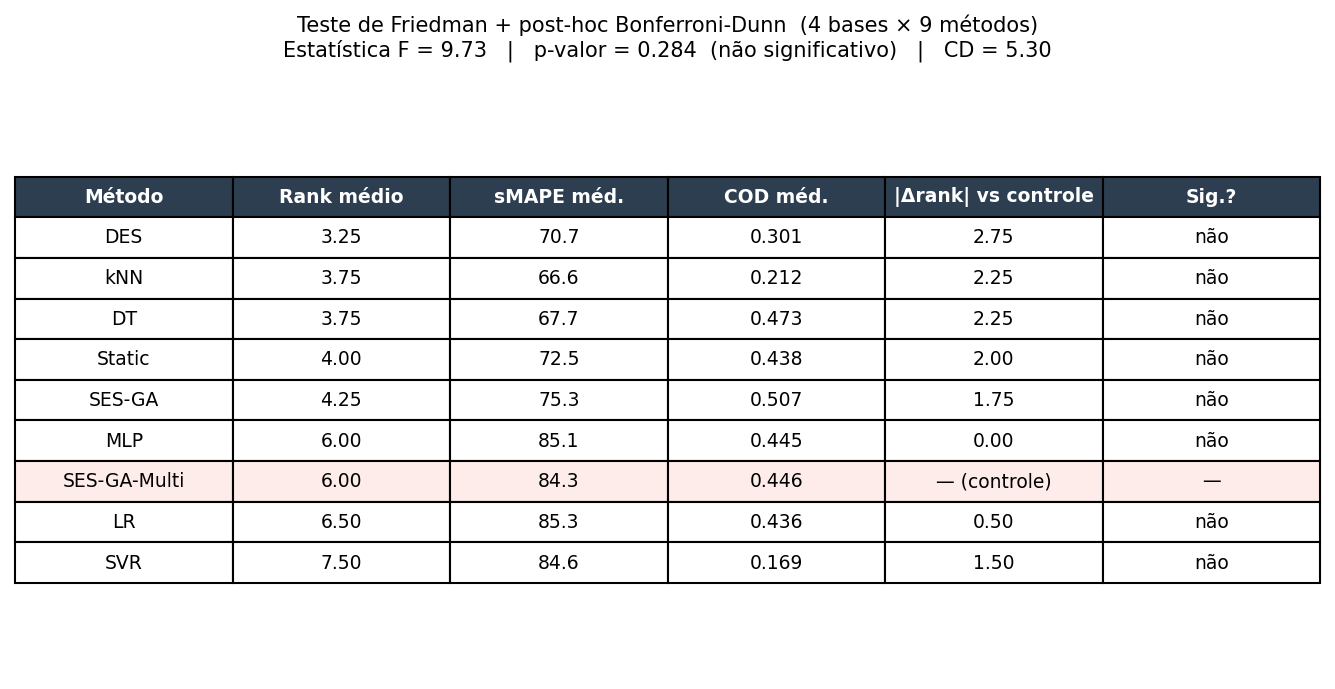

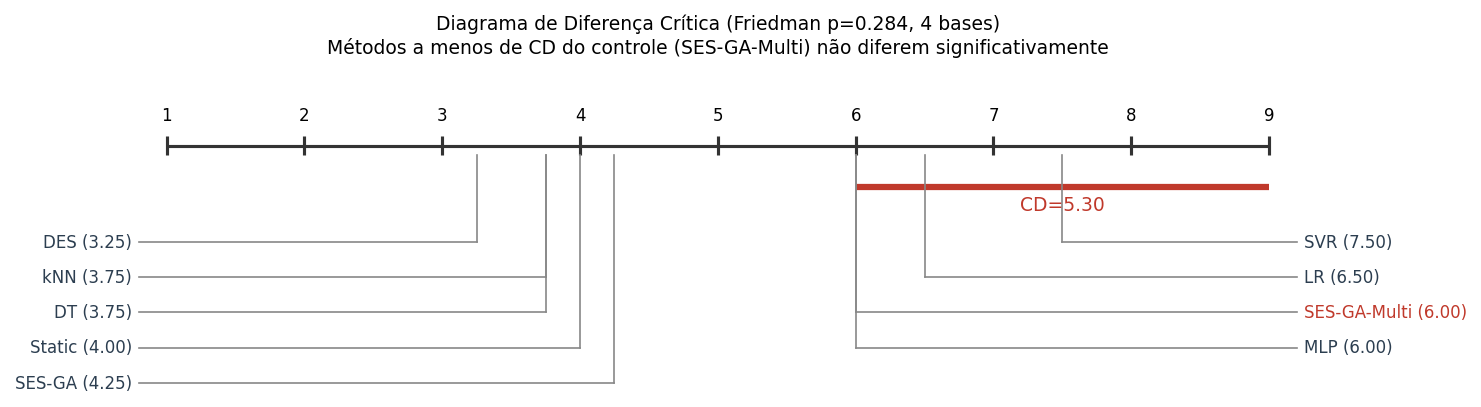

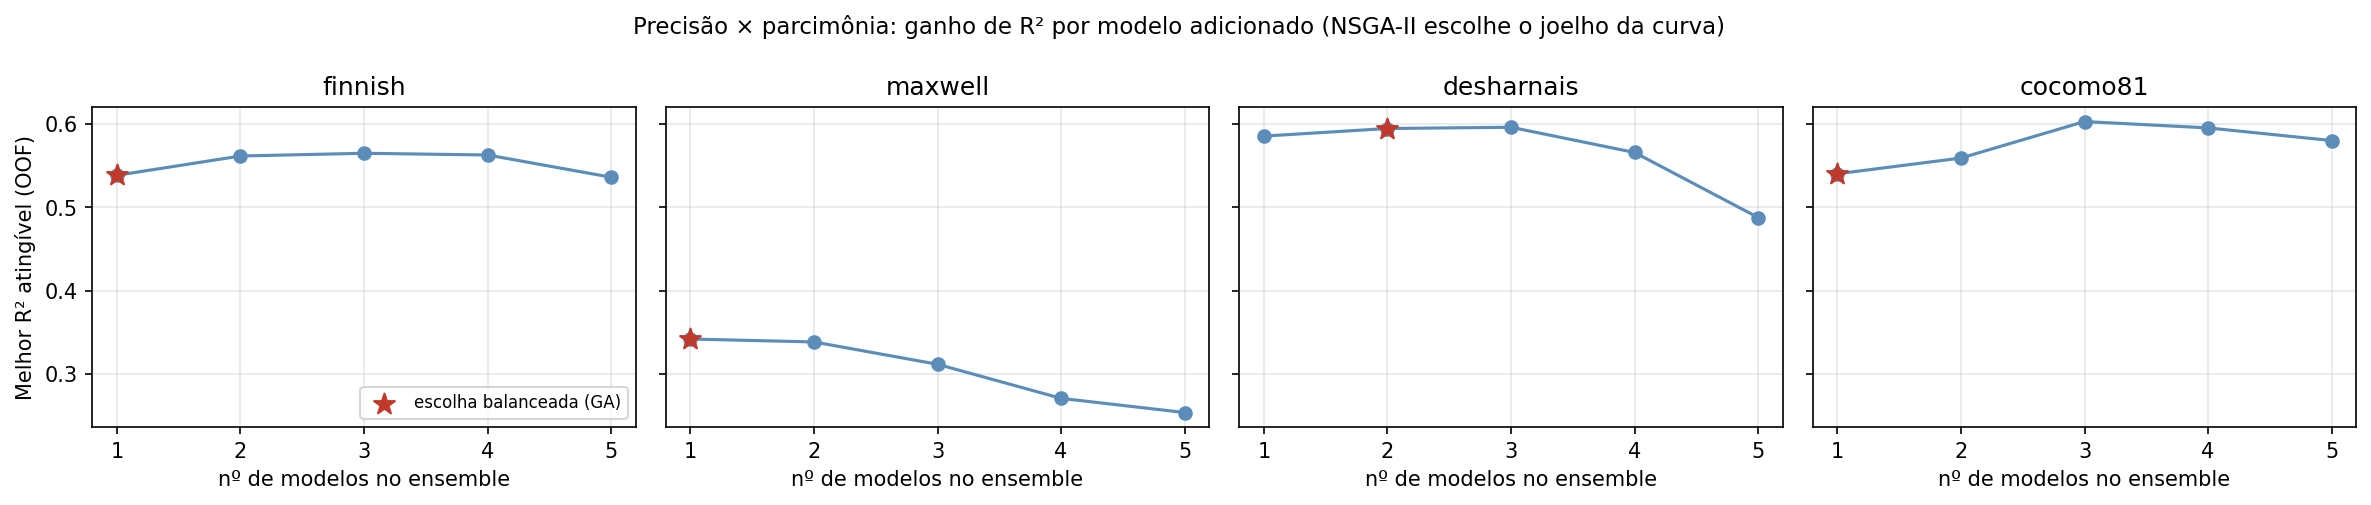

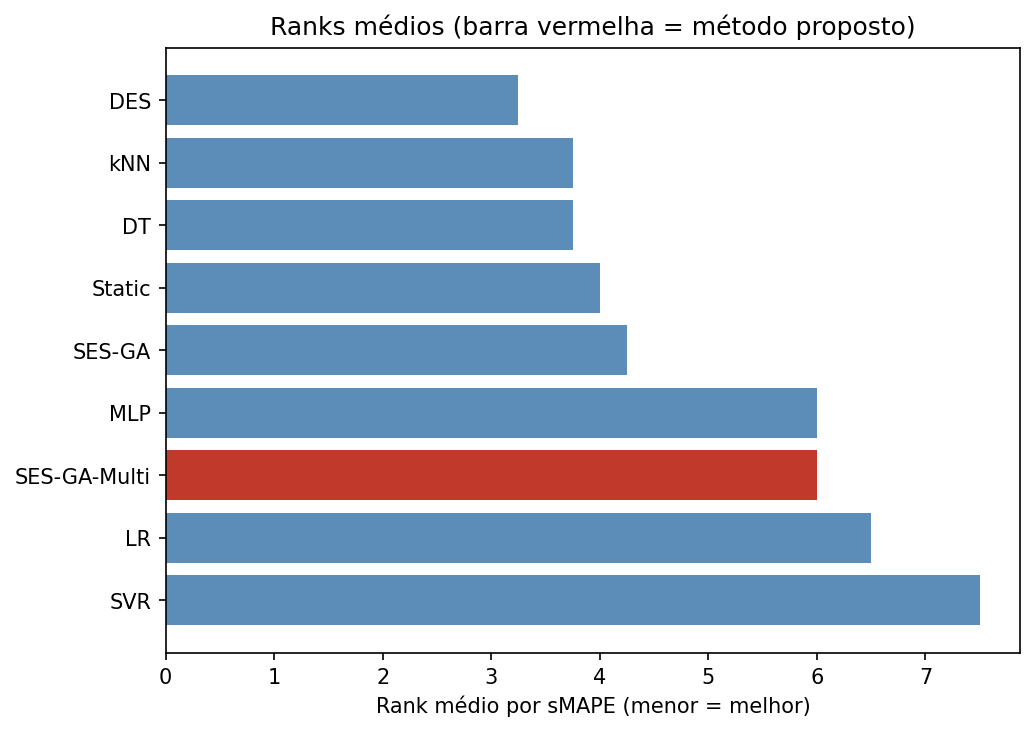

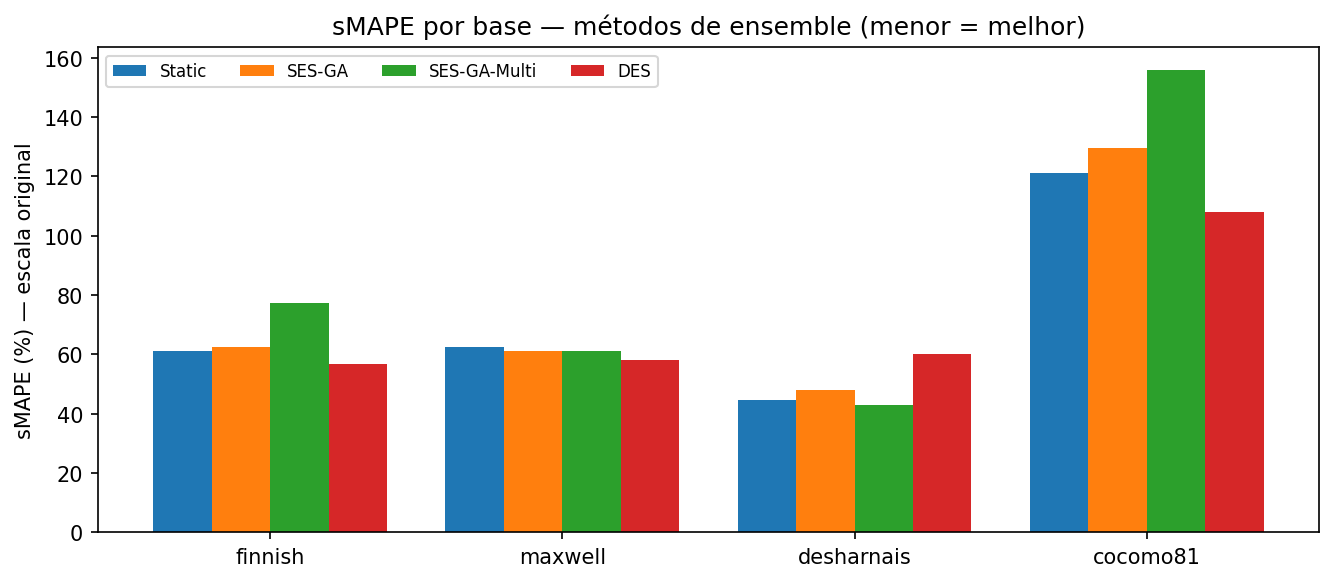

In [15]:
import pandas as pd
from IPython.display import Image, display

print('Tabela de métricas (média entre bases):')
display(pd.read_csv('results/tabela_metricas.csv'))

for fig in ['5_tabela_friedman','1_diagrama_diferenca_critica',
            '3_frente_pareto','2_ranks_medios','4_smape_por_base']:
    display(Image(filename=f'results/figuras/{fig}.png'))